# Assignment 4 — Tabular RL Methods: Windy Gridworld
### MMAI-845 · Reinforcement Learning · Spring 2026

This notebook walks through the **Windy Gridworld** environment and implements two tabular RL algorithms:
1. **SARSA** (on-policy TD control)
2. **Q-Learning** (off-policy TD control)

We'll build intuition step-by-step, run experiments with different hyperparameters, and visualize the results.

---

## 1. Setup & Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Inline plots for Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Setup complete.")

Setup complete.


## 2. Understanding the Windy Gridworld Environment

### The Grid
- **10 columns × 7 rows** grid. Each cell is a state `(x, y)`.
- **Start**: `(0, 3)` — left side, middle row
- **Goal**: `(7, 4)` — right side, one row above middle

### Actions
Four deterministic moves: **UP, DOWN, RIGHT, LEFT** — each shifts the agent by one cell.

### The Wind
Certain columns have an **upward crosswind** that pushes the agent up *in addition* to their chosen action:
```
Column:  0  1  2  3  4  5  6  7  8  9
Wind:    0  0  0  1  1  1  2  2  1  0
```
For example, if you're in column 6 (wind=2) and move RIGHT, you end up 1 cell to the right **and 2 cells up**.

### Rewards & Objective
- Every action costs **−1** reward (including the final step to the goal).
- Episode ends when the agent reaches the goal.
- Since γ = 1, total reward = −(number of steps). The **optimal path takes ~14 steps** → total reward = **−14**.

Let's visualize this grid:

In [19]:
# ── Environment Definition ──────────────────────────────────────

# Action vectors: how each action changes (x, y)
UP    = np.array([0, 1])
DOWN  = np.array([0, -1])
RIGHT = np.array([1, 0])
LEFT  = np.array([-1, 0])

ACTIONS = [UP, DOWN, RIGHT, LEFT]
ACTION_NAMES = ['↑ UP', '↓ DOWN', '→ RIGHT', '← LEFT']
ACTION_ARROWS = ['↑', '↓', '→', '←']

class WindyGridWorld:
    """Windy Gridworld environment (simplified, no gym dependency needed)."""
    
    def __init__(self):
        self.grid_width = 10
        self.grid_height = 7
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0])
        self.start = np.array([0, 3])
        self.goal  = np.array([7, 4])
        self.n_actions = len(ACTIONS)
        self.state = self.start.copy()
        self.max_steps = 1000
        self.step_count = 0
    
    def reset(self):
        self.state = self.start.copy()
        self.step_count = 0
        return self.state.copy()
    
    def step(self, action_idx):
        self.step_count += 1
        action = ACTIONS[action_idx]
        
        # Apply action + wind
        next_state = self.state + action
        next_state[1] += self.wind[self.state[0]]  # wind pushes UP based on current column
        
        # Clip to grid boundaries
        next_state[0] = np.clip(next_state[0], 0, self.grid_width - 1)
        next_state[1] = np.clip(next_state[1], 0, self.grid_height - 1)
        
        self.state = next_state
        done = np.array_equal(next_state, self.goal) or (self.step_count > self.max_steps)
        reward = -1
        
        return self.state.copy(), reward, done, {}

env = WindyGridWorld()
print(f"Grid size:    {env.grid_width} × {env.grid_height}")
print(f"Start:        {env.start}")
print(f"Goal:         {env.goal}")
print(f"Wind:         {env.wind}")
print(f"Num actions:  {env.n_actions}")

Grid size:    10 × 7
Start:        [0 3]
Goal:         [7 4]
Wind:         [0 0 0 1 1 1 2 2 1 0]
Num actions:  4


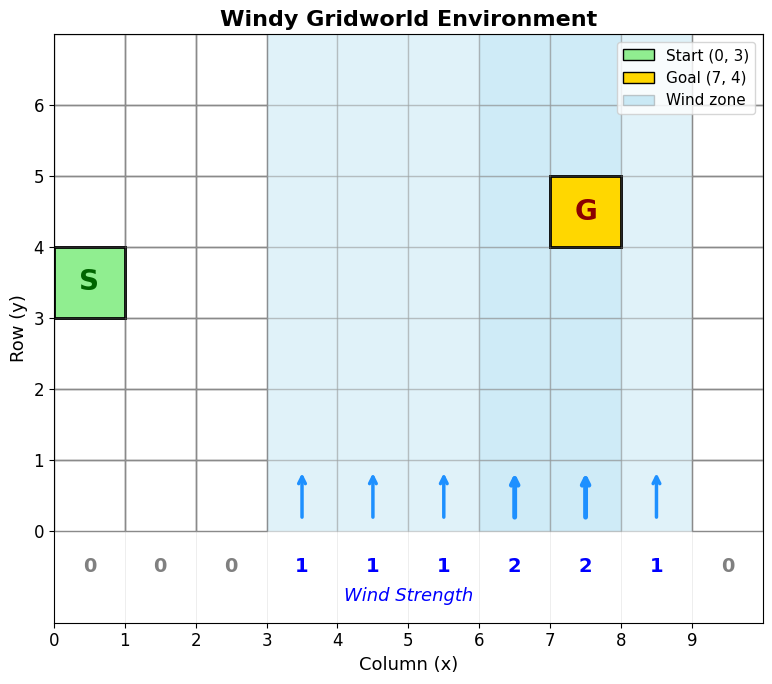

In [20]:
# ── Visualize the Grid ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

# Draw grid cells
for x in range(env.grid_width):
    for y in range(env.grid_height):
        # Color wind columns
        wind_strength = env.wind[x]
        if wind_strength > 0:
            alpha = 0.1 + 0.15 * wind_strength
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=True, 
                                        facecolor='skyblue', alpha=alpha, edgecolor='gray'))
        else:
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))

# Mark start and goal
ax.add_patch(plt.Rectangle((env.start[0], env.start[1]), 1, 1, 
                             facecolor='#90EE90', edgecolor='black', linewidth=2))
ax.text(env.start[0]+0.5, env.start[1]+0.5, 'S', ha='center', va='center', 
        fontsize=20, fontweight='bold', color='darkgreen')

ax.add_patch(plt.Rectangle((env.goal[0], env.goal[1]), 1, 1, 
                             facecolor='#FFD700', edgecolor='black', linewidth=2))
ax.text(env.goal[0]+0.5, env.goal[1]+0.5, 'G', ha='center', va='center', 
        fontsize=20, fontweight='bold', color='darkred')

# Wind arrows and labels
for x in range(env.grid_width):
    w = env.wind[x]
    ax.text(x+0.5, -0.5, str(w), ha='center', va='center', fontsize=14, fontweight='bold',
            color='blue' if w > 0 else 'gray')
    if w > 0:
        ax.annotate('', xy=(x+0.5, 0.85), xytext=(x+0.5, 0.15),
                    arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=1.5+w))

ax.text(5, -1.0, 'Wind Strength', ha='center', fontsize=13, fontstyle='italic', color='blue')

ax.set_xlim(0, env.grid_width)
ax.set_ylim(-1.3, env.grid_height)
ax.set_aspect('equal')
ax.set_xticks(range(env.grid_width))
ax.set_yticks(range(env.grid_height))
ax.set_xlabel('Column (x)', fontsize=13)
ax.set_ylabel('Row (y)', fontsize=13)
ax.set_title('Windy Gridworld Environment', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#90EE90', edgecolor='black', label='Start (0, 3)'),
    mpatches.Patch(facecolor='#FFD700', edgecolor='black', label='Goal (7, 4)'),
    mpatches.Patch(facecolor='skyblue', alpha=0.4, edgecolor='gray', label='Wind zone'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### Quick Demo: How the Wind Works

Let's manually step through a few actions to see the wind in action:

In [21]:
# ── Demo: Step through the environment ──────────────────────────

env_demo = WindyGridWorld()
state = env_demo.reset()
print(f"Start state: {state}")
print(f"{'─'*50}")

demo_actions = [2, 2, 2, 2, 0, 2, 2, 2]  # RIGHT RIGHT RIGHT RIGHT UP RIGHT RIGHT RIGHT
action_labels = ['RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'UP', 'RIGHT', 'RIGHT', 'RIGHT']

for i, (act, label) in enumerate(zip(demo_actions, action_labels)):
    old_state = state.copy()
    wind = env_demo.wind[old_state[0]]
    state, reward, done, _ = env_demo.step(act)
    print(f"Step {i+1}: At {old_state} → action {label:5s} (wind={wind}) → landed at {state}  [reward={reward}]")
    if done:
        print(f"\n🎯 Reached goal in {i+1} steps! Total reward = {-(i+1)}")
        break

if not done:
    print(f"\nDid not reach goal in {len(demo_actions)} steps. Current position: {state}")

Start state: [0 3]
──────────────────────────────────────────────────
Step 1: At [0 3] → action RIGHT (wind=0) → landed at [1 3]  [reward=-1]
Step 2: At [1 3] → action RIGHT (wind=0) → landed at [2 3]  [reward=-1]
Step 3: At [2 3] → action RIGHT (wind=0) → landed at [3 3]  [reward=-1]
Step 4: At [3 3] → action RIGHT (wind=1) → landed at [4 4]  [reward=-1]
Step 5: At [4 4] → action UP    (wind=1) → landed at [4 6]  [reward=-1]
Step 6: At [4 6] → action RIGHT (wind=1) → landed at [5 6]  [reward=-1]
Step 7: At [5 6] → action RIGHT (wind=1) → landed at [6 6]  [reward=-1]
Step 8: At [6 6] → action RIGHT (wind=2) → landed at [7 6]  [reward=-1]

Did not reach goal in 8 steps. Current position: [7 6]


## 3. ε-Greedy Action Selection

Before implementing the algorithms, let's understand the exploration strategy.

**ε-greedy** works as follows:
- With probability **(1 − ε)**: pick the **greedy** action (highest Q-value)  
- With probability **ε**: pick a **random** action (exploration)

The ε is distributed uniformly across all actions, so the greedy action actually gets probability `(1 − ε) + ε/n_actions`.

In [22]:
# ── Epsilon-Greedy Action Selection ─────────────────────────────

def epsilon_greedy_action(q_values, epsilon):
    """
    Select action using epsilon-greedy strategy.
    
    Args:
        q_values: Q-values for all actions at current state, shape (n_actions,)
        epsilon:  probability of random exploration
    
    Returns:
        action index
    """
    n_actions = len(q_values)
    probs = np.zeros(n_actions)
    
    # Greedy action gets the bulk of the probability
    best_action = np.argmax(q_values)
    probs[best_action] = 1.0 - epsilon
    
    # Spread epsilon equally across ALL actions (including greedy)
    probs += epsilon / n_actions
    
    return np.random.choice(n_actions, p=probs)

# Demo: show the probability distribution
print("Example: Q-values = [−5.0, −3.2, −8.0, −4.1], ε = 0.05")
print(f"  Best action index = 1 (highest Q = −3.2)")
print(f"  P(action 1) = (1 − 0.05) + 0.05/4 = {1 - 0.05 + 0.05/4:.4f}")
print(f"  P(other)    = 0.05/4                = {0.05/4:.4f}")
print(f"  Sum = {(1 - 0.05 + 0.05/4) + 3*(0.05/4):.4f}")

Example: Q-values = [−5.0, −3.2, −8.0, −4.1], ε = 0.05
  Best action index = 1 (highest Q = −3.2)
  P(action 1) = (1 − 0.05) + 0.05/4 = 0.9625
  P(other)    = 0.05/4                = 0.0125
  Sum = 1.0000


## 4. SARSA (On-Policy TD Control)

### The Algorithm (from Sutton & Barto, page 130)

```
Initialize Q(s, a) for all s, a arbitrarily; Q(terminal, ·) = 0

Loop for each episode:
    Initialize S
    Choose A from S using policy derived from Q (ε-greedy)
    
    Loop for each step of episode:
        Take action A, observe R, S'
        Choose A' from S' using policy derived from Q (ε-greedy)
        Q(S, A) ← Q(S, A) + α [ R + γ Q(S', A') − Q(S, A) ]
        S ← S';  A ← A'
    until S is terminal
```

### Why "SARSA"?
The name comes from the quintuple used in each update: **(S, A, R, S', A')**.

### Key Insight: On-Policy
SARSA updates Q using the **actual next action A'** that the agent will take (chosen by ε-greedy). This means SARSA learns the value of the policy *it is actually following* (including exploration mistakes). It's more conservative — it accounts for the fact that the agent sometimes explores randomly.

In [23]:
# ── SARSA Implementation ────────────────────────────────────────

def sarsa(env, step_size=0.5, epsilon=0.1, gamma=1.0, num_eps=100, verbose=False):
    """
    SARSA: On-policy TD control.
    
    Args:
        env:       WindyGridWorld environment
        step_size: α — learning rate (how much to update Q per step)
        epsilon:   ε — exploration rate
        gamma:     γ — discount factor (1.0 for undiscounted)
        num_eps:   number of training episodes
        verbose:   print progress every 50 episodes
    
    Returns:
        reward_list: total reward per episode
        q_table:     learned Q-values, shape (width, height, n_actions)
    """
    # Initialize Q-table to zeros (terminal state stays 0 since we never update it)
    q_table = np.zeros((env.grid_width, env.grid_height, env.n_actions))
    reward_list = []
    
    for ep in range(num_eps):
        # ─── Initialize S ───
        state = env.reset()
        done = False
        ep_reward = 0
        
        # ─── Choose A from S using ε-greedy (BEFORE the loop — this is key for SARSA) ───
        action = epsilon_greedy_action(q_table[state[0], state[1], :], epsilon)
        
        # ─── Loop for each step ───
        while not done:
            # Take action A, observe R, S'
            state_prime, reward, done, _ = env.step(action)
            
            # Choose A' from S' using ε-greedy
            action_prime = epsilon_greedy_action(q_table[state_prime[0], state_prime[1], :], epsilon)
            
            # ━━━ SARSA UPDATE (Task 1.1) ━━━
            # Q(S,A) ← Q(S,A) + α [ R + γ·Q(S',A') − Q(S,A) ]
            q_current = q_table[state[0], state[1], action]
            q_next    = q_table[state_prime[0], state_prime[1], action_prime]
            
            td_target = reward + gamma * q_next          # what we observed + future estimate
            td_error  = td_target - q_current             # how wrong our current estimate was
            q_table[state[0], state[1], action] += step_size * td_error  # nudge Q toward target
            
            # S ← S';  A ← A'
            state  = state_prime
            action = action_prime
            ep_reward += reward
        
        reward_list.append(ep_reward)
        
        if verbose and (ep + 1) % 50 == 0:
            recent_avg = np.mean(reward_list[-50:])
            print(f"  Episode {ep+1:4d} | Last 50 avg reward: {recent_avg:.1f}")
    
    return reward_list, q_table

print("SARSA function defined. ✓")

SARSA function defined. ✓


## 5. Q-Learning (Off-Policy TD Control)

### The Algorithm (from Sutton & Barto, page 131)

```
Initialize Q(s, a) for all s, a arbitrarily; Q(terminal, ·) = 0

Loop for each episode:
    Initialize S
    
    Loop for each step of episode:
        Choose A from S using policy derived from Q (ε-greedy)
        Take action A, observe R, S'
        Q(S, A) ← Q(S, A) + α [ R + γ max_a Q(S', a) − Q(S, A) ]
        S ← S'
    until S is terminal
```

### Key Difference from SARSA

| Aspect | SARSA | Q-Learning |
|---|---|---|
| **Update uses** | Q(S', **A'**) — the actual next action | **max**_a Q(S', a) — the best possible action |
| **Policy type** | On-policy (learns value of what it does) | Off-policy (learns optimal value regardless of what it does) |
| **Action selection** | A chosen outside loop, A' inside loop | A chosen inside loop, no A' needed |
| **Behavior** | More conservative (accounts for exploration) | More aggressive (assumes future is optimal) |

### Why "Off-Policy"?
Q-Learning uses `max` in its update, assuming the agent will act **optimally** in the future — even though the agent is actually following an ε-greedy policy that sometimes explores. It learns the value of the *optimal* policy while *behaving* with a different (exploratory) policy.

In [24]:
# ── Q-Learning Implementation ───────────────────────────────────

def q_learning(env, step_size=0.5, epsilon=0.1, gamma=1.0, num_eps=100, verbose=False):
    """
    Q-Learning: Off-policy TD control.
    
    Args:
        env:       WindyGridWorld environment
        step_size: α — learning rate
        epsilon:   ε — exploration rate
        gamma:     γ — discount factor
        num_eps:   number of training episodes
        verbose:   print progress
    
    Returns:
        reward_list: total reward per episode
        q_table:     learned Q-values, shape (width, height, n_actions)
    """
    q_table = np.zeros((env.grid_width, env.grid_height, env.n_actions))
    reward_list = []
    
    for ep in range(num_eps):
        # ─── Initialize S ───
        state = env.reset()
        done = False
        ep_reward = 0
        
        # ─── Loop for each step ───
        while not done:
            # Choose A from S using ε-greedy (INSIDE the loop — different from SARSA)
            action = epsilon_greedy_action(q_table[state[0], state[1], :], epsilon)
            
            # Take action A, observe R, S'
            state_prime, reward, done, _ = env.step(action)
            
            # ━━━ Q-LEARNING UPDATE (Tasks 2.1 + 2.2) ━━━
            # Task 2.1: Find max_a Q(S', a)
            q_current = q_table[state[0], state[1], action]
            q_best_next = np.max(q_table[state_prime[0], state_prime[1], :])  # ← max, not A'
            
            # Task 2.2: Q(S,A) ← Q(S,A) + α [ R + γ·max_a Q(S',a) − Q(S,A) ]
            td_target = reward + gamma * q_best_next
            td_error  = td_target - q_current
            q_table[state[0], state[1], action] += step_size * td_error
            
            # S ← S'  (no A ← A' needed — action is chosen fresh each step)
            state = state_prime
            ep_reward += reward
        
        reward_list.append(ep_reward)
        
        if verbose and (ep + 1) % 50 == 0:
            recent_avg = np.mean(reward_list[-50:])
            print(f"  Episode {ep+1:4d} | Last 50 avg reward: {recent_avg:.1f}")
    
    return reward_list, q_table

print("Q-Learning function defined. ✓")

Q-Learning function defined. ✓


## 6. Visualization Helpers

In [25]:
# ── Visualization Helpers ───────────────────────────────────────

def plot_rewards(reward_list, title, window=20):
    """Plot episode rewards with a rolling average."""
    fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(reward_list, alpha=0.3, color='steelblue', label='Per episode')
    
    # Rolling average
    if len(reward_list) >= window:
        rolling = np.convolve(reward_list, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(reward_list)), rolling, color='darkblue', 
                linewidth=2, label=f'{window}-episode moving avg')
    
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.7, label='Optimal (−14)')
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.7, label='Target (≥ −16)')
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(f'{title} — Training Rewards')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_policy(q_table, env, title):
    """Plot the greedy policy as arrows on the grid."""
    fig, ax = plt.subplots(figsize=(12, 7))
    
    arrow_map = {0: (0, 0.3), 1: (0, -0.3), 2: (0.3, 0), 3: (-0.3, 0)}  # UP DOWN RIGHT LEFT
    
    for x in range(env.grid_width):
        for y in range(env.grid_height):
            # Background color for wind
            w = env.wind[x]
            if w > 0:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor='skyblue', 
                                            alpha=0.1+0.15*w, edgecolor='gray'))
            else:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))
            
            # Arrow for greedy action
            best_action = np.argmax(q_table[x, y, :])
            dx, dy = arrow_map[best_action]
            ax.arrow(x+0.5, y+0.5, dx, dy, head_width=0.08, head_length=0.08,
                     fc='black', ec='black', linewidth=1.2)
    
    # Start and Goal
    ax.add_patch(plt.Rectangle((env.start[0], env.start[1]), 1, 1, 
                                 facecolor='#90EE90', alpha=0.7, edgecolor='black', lw=2))
    ax.text(env.start[0]+0.5, env.start[1]+0.5, 'S', ha='center', va='center', 
            fontsize=16, fontweight='bold', color='darkgreen')
    
    ax.add_patch(plt.Rectangle((env.goal[0], env.goal[1]), 1, 1, 
                                 facecolor='#FFD700', alpha=0.7, edgecolor='black', lw=2))
    ax.text(env.goal[0]+0.5, env.goal[1]+0.5, 'G', ha='center', va='center', 
            fontsize=16, fontweight='bold', color='darkred')
    
    # Wind labels
    for x in range(env.grid_width):
        ax.text(x+0.5, -0.4, str(env.wind[x]), ha='center', fontsize=13, 
                fontweight='bold', color='blue' if env.wind[x] > 0 else 'gray')
    
    ax.set_xlim(0, env.grid_width)
    ax.set_ylim(-0.8, env.grid_height)
    ax.set_aspect('equal')
    ax.set_title(f'Greedy Policy — {title}', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(env.grid_width))
    ax.set_yticks(range(env.grid_height))
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.tight_layout()
    plt.show()


def evaluate_policy(q_table, env, max_steps=50):
    """Run the greedy policy (no exploration) and return total reward + path."""
    state = env.reset()
    path = [state.copy()]
    total_reward = 0
    
    for step in range(max_steps):
        action = np.argmax(q_table[state[0], state[1], :])
        state, reward, done, _ = env.step(action)
        path.append(state.copy())
        total_reward += reward
        if done:
            break
    
    return total_reward, path


def plot_path(path, env, title):
    """Plot the agent's path on the grid."""
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Grid background
    for x in range(env.grid_width):
        for y in range(env.grid_height):
            w = env.wind[x]
            if w > 0:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor='skyblue',
                                            alpha=0.1+0.15*w, edgecolor='gray'))
            else:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))
    
    # Start/Goal
    ax.add_patch(plt.Rectangle((env.start[0], env.start[1]), 1, 1, 
                                 facecolor='#90EE90', alpha=0.5, edgecolor='black', lw=2))
    ax.text(env.start[0]+0.5, env.start[1]+0.5, 'S', ha='center', va='center', 
            fontsize=16, fontweight='bold', color='darkgreen')
    ax.add_patch(plt.Rectangle((env.goal[0], env.goal[1]), 1, 1, 
                                 facecolor='#FFD700', alpha=0.5, edgecolor='black', lw=2))
    ax.text(env.goal[0]+0.5, env.goal[1]+0.5, 'G', ha='center', va='center', 
            fontsize=16, fontweight='bold', color='darkred')
    
    # Path
    xs = [p[0]+0.5 for p in path]
    ys = [p[1]+0.5 for p in path]
    ax.plot(xs, ys, 'ro-', markersize=6, linewidth=2, alpha=0.7, label=f'Path ({len(path)-1} steps)')
    ax.plot(xs[0], ys[0], 'gs', markersize=12)  # start marker
    ax.plot(xs[-1], ys[-1], 'r*', markersize=15)  # end marker
    
    # Step numbers
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8, color='red')
    
    # Wind labels
    for x in range(env.grid_width):
        ax.text(x+0.5, -0.4, str(env.wind[x]), ha='center', fontsize=13,
                fontweight='bold', color='blue' if env.wind[x] > 0 else 'gray')
    
    ax.set_xlim(0, env.grid_width)
    ax.set_ylim(-0.8, env.grid_height)
    ax.set_aspect('equal')
    ax.set_title(f'{title} — Agent Path', fontsize=15, fontweight='bold')
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(env.grid_width))
    ax.set_yticks(range(env.grid_height))
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.tight_layout()
    plt.show()

print("Visualization helpers defined. ✓")

Visualization helpers defined. ✓


## 7. Run SARSA

### Hyperparameters (Task 1.2)
The assignment says:
- **α (step_size)**: Keep between 0 and 1. Controls how aggressively Q-values update.
- **ε (epsilon)**: Keep small, < 10%. Controls exploration vs exploitation.
- **num_eps**: Run enough episodes for rewards to flatten/stabilize.

Let's start with well-tuned parameters:

In [26]:
# ── Run SARSA ───────────────────────────────────────────────────

np.random.seed(42)
env = WindyGridWorld()

print("══════ Running SARSA ══════")
print(f"Parameters: α=0.5, ε=0.05, γ=1.0, episodes=500\n")

sarsa_rewards, sarsa_table = sarsa(
    env, 
    step_size=0.5,    # α: moderate learning rate
    epsilon=0.05,     # ε: 5% random exploration
    gamma=1.0,        # γ: undiscounted (as required)
    num_eps=500,      # enough to converge
    verbose=True
)

# Evaluate the learned policy (greedy, no exploration)
sarsa_total, sarsa_path = evaluate_policy(sarsa_table, env)
print(f"\n✅ SARSA greedy policy reward: {sarsa_total}")
print(f"   Optimal reward:             -14")
print(f"   Target (pass):              ≥ -16")
print(f"   {'PASS ✓' if sarsa_total >= -16 else 'NEEDS TUNING ✗'}")

══════ Running SARSA ══════
Parameters: α=0.5, ε=0.05, γ=1.0, episodes=500

  Episode   50 | Last 50 avg reward: -87.9
  Episode  100 | Last 50 avg reward: -29.0
  Episode  150 | Last 50 avg reward: -19.0
  Episode  200 | Last 50 avg reward: -19.2
  Episode  250 | Last 50 avg reward: -18.9
  Episode  300 | Last 50 avg reward: -19.1
  Episode  350 | Last 50 avg reward: -15.4
  Episode  400 | Last 50 avg reward: -15.2
  Episode  450 | Last 50 avg reward: -19.1
  Episode  500 | Last 50 avg reward: -15.7

✅ SARSA greedy policy reward: -14
   Optimal reward:             -14
   Target (pass):              ≥ -16
   PASS ✓


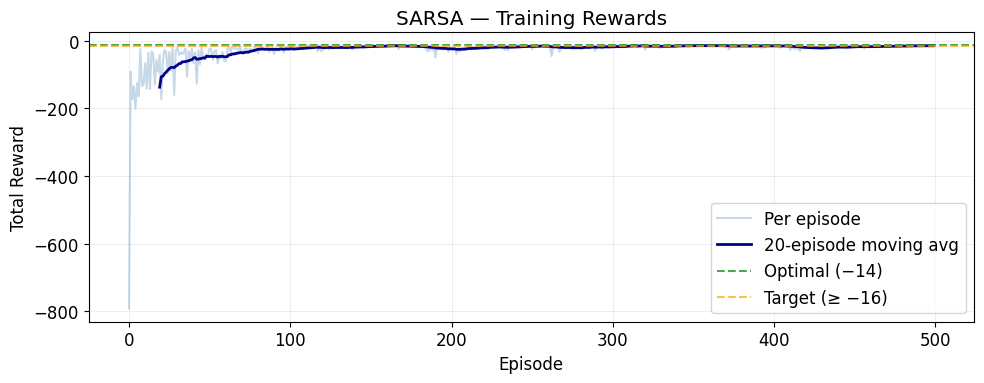

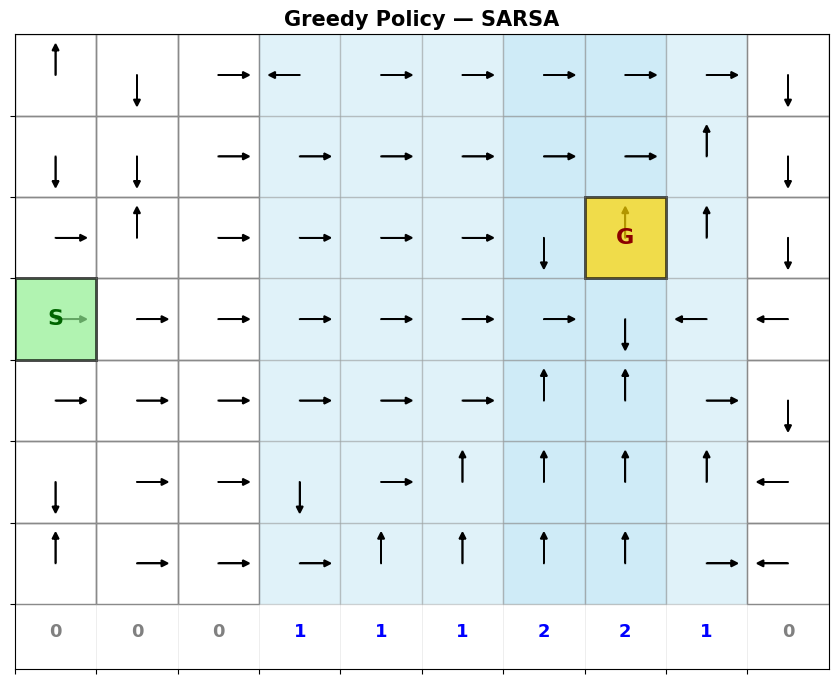

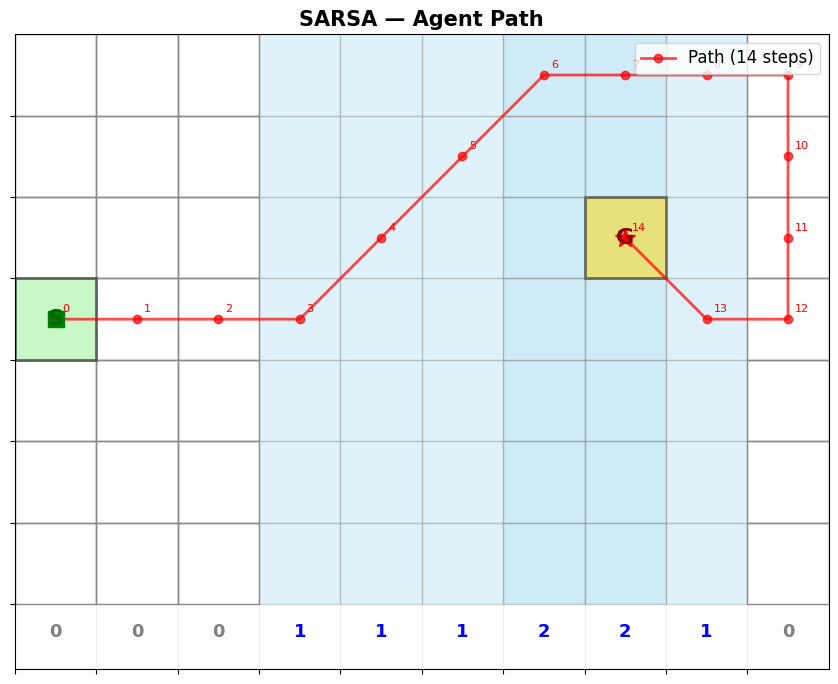

In [27]:
# ── SARSA Results ───────────────────────────────────────────────

plot_rewards(sarsa_rewards, 'SARSA')
plot_policy(sarsa_table, env, 'SARSA')
plot_path(sarsa_path, env, 'SARSA')

## 8. Run Q-Learning

Same hyperparameter constraints as SARSA. Let's use similar values:

In [28]:
# ── Run Q-Learning ──────────────────────────────────────────────

np.random.seed(42)
env = WindyGridWorld()

print("══════ Running Q-Learning ══════")
print(f"Parameters: α=0.5, ε=0.05, γ=1.0, episodes=500\n")

ql_rewards, ql_table = q_learning(
    env,
    step_size=0.5,
    epsilon=0.05,
    gamma=1.0,
    num_eps=500,
    verbose=True
)

ql_total, ql_path = evaluate_policy(ql_table, env)
print(f"\n✅ Q-Learning greedy policy reward: {ql_total}")
print(f"   Optimal reward:                  -14")
print(f"   Target (pass):                   ≥ -16")
print(f"   {'PASS ✓' if ql_total >= -16 else 'NEEDS TUNING ✗'}")

══════ Running Q-Learning ══════
Parameters: α=0.5, ε=0.05, γ=1.0, episodes=500

  Episode   50 | Last 50 avg reward: -72.8
  Episode  100 | Last 50 avg reward: -30.3
  Episode  150 | Last 50 avg reward: -18.0
  Episode  200 | Last 50 avg reward: -15.3
  Episode  250 | Last 50 avg reward: -15.0
  Episode  300 | Last 50 avg reward: -15.3
  Episode  350 | Last 50 avg reward: -15.2
  Episode  400 | Last 50 avg reward: -14.7
  Episode  450 | Last 50 avg reward: -15.2
  Episode  500 | Last 50 avg reward: -14.7

✅ Q-Learning greedy policy reward: -14
   Optimal reward:                  -14
   Target (pass):                   ≥ -16
   PASS ✓


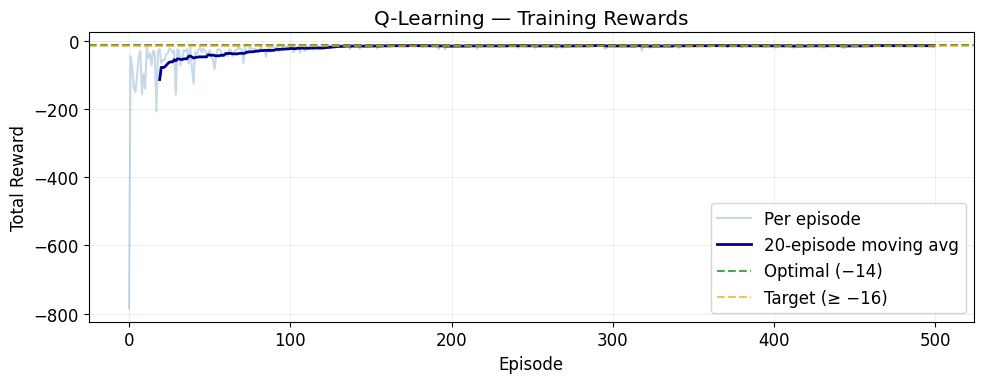

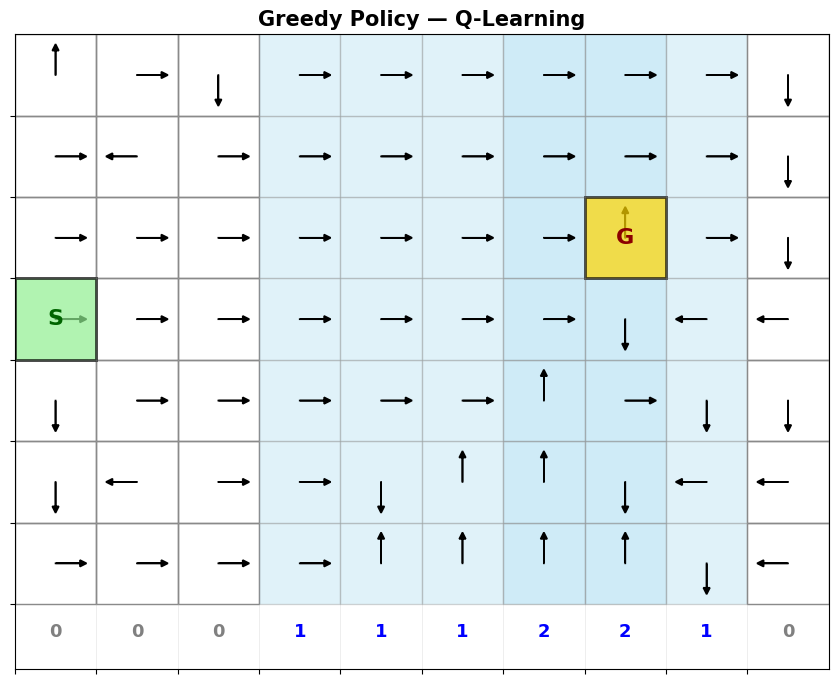

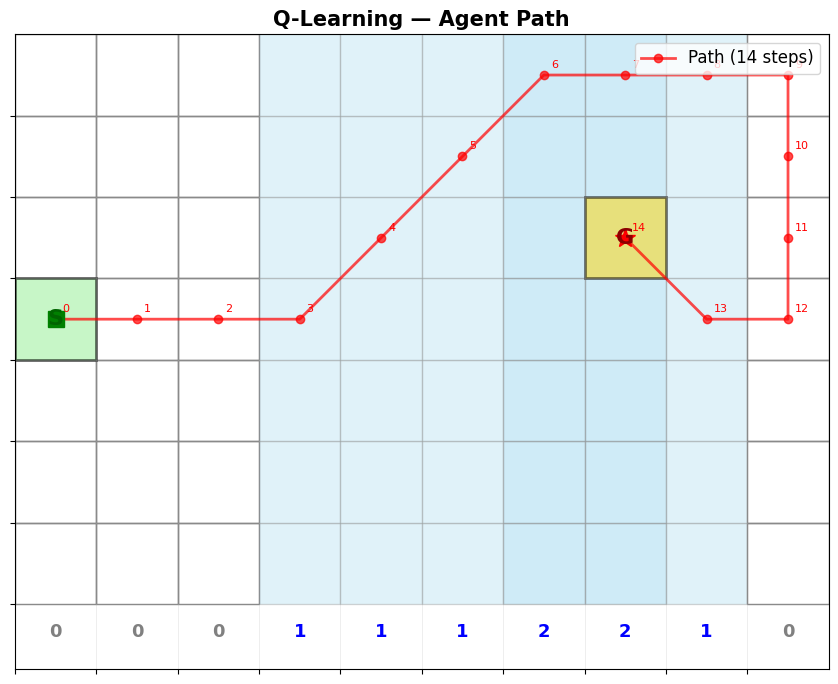

In [29]:
# ── Q-Learning Results ──────────────────────────────────────────

plot_rewards(ql_rewards, 'Q-Learning')
plot_policy(ql_table, env, 'Q-Learning')
plot_path(ql_path, env, 'Q-Learning')

## 9. Side-by-Side Comparison

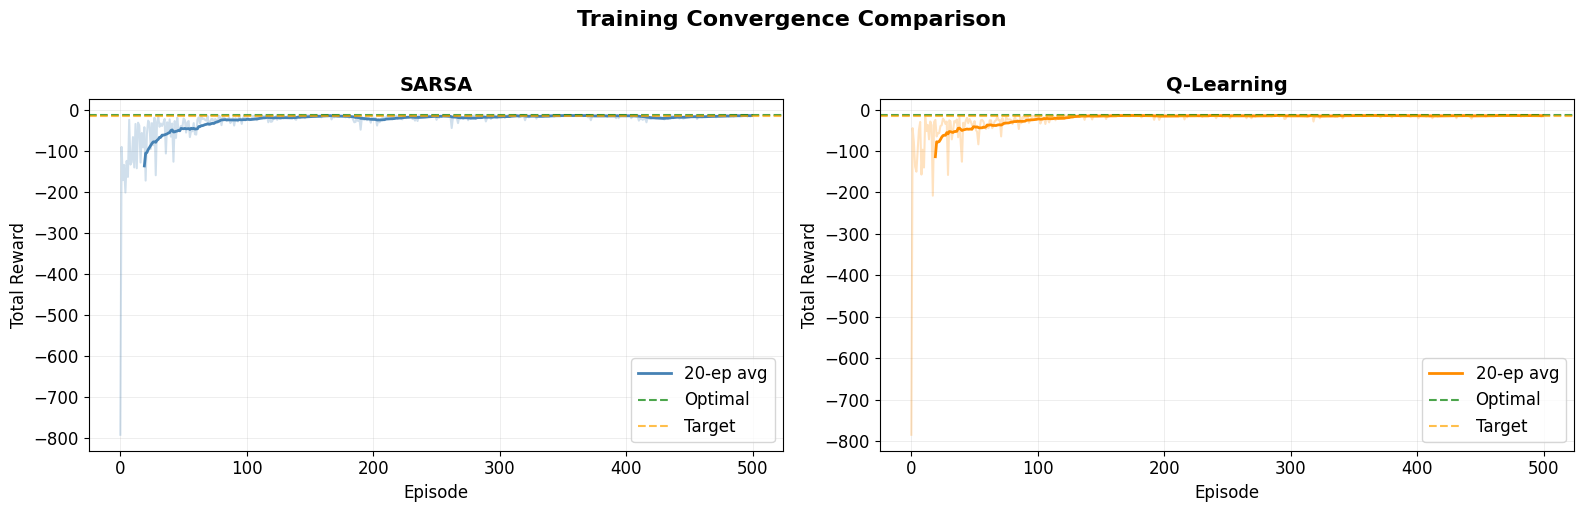

SARSA greedy reward:      -14
Q-Learning greedy reward: -14
SARSA path length:        14 steps
Q-Learning path length:   14 steps


In [30]:
# ── Compare SARSA vs Q-Learning ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window = 20
for ax, rewards, name, color in [
    (axes[0], sarsa_rewards, 'SARSA', 'steelblue'),
    (axes[1], ql_rewards, 'Q-Learning', 'darkorange')
]:
    ax.plot(rewards, alpha=0.25, color=color)
    if len(rewards) >= window:
        rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), rolling, color=color, linewidth=2, label=f'{window}-ep avg')
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.7, label='Optimal')
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.7, label='Target')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Convergence Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"SARSA greedy reward:      {sarsa_total}")
print(f"Q-Learning greedy reward: {ql_total}")
print(f"SARSA path length:        {len(sarsa_path)-1} steps")
print(f"Q-Learning path length:   {len(ql_path)-1} steps")

## 10. Hyperparameter Experiments

The assignment asks you to *understand the effect* of each parameter. Let's systematically test them.

### Experiment 1: Effect of Learning Rate (α)

**α controls how much the Q-value changes per update.**
- Too small → learns slowly, may not converge in time
- Too large → overshoots, Q-values oscillate
- Sweet spot → fast convergence, stable values

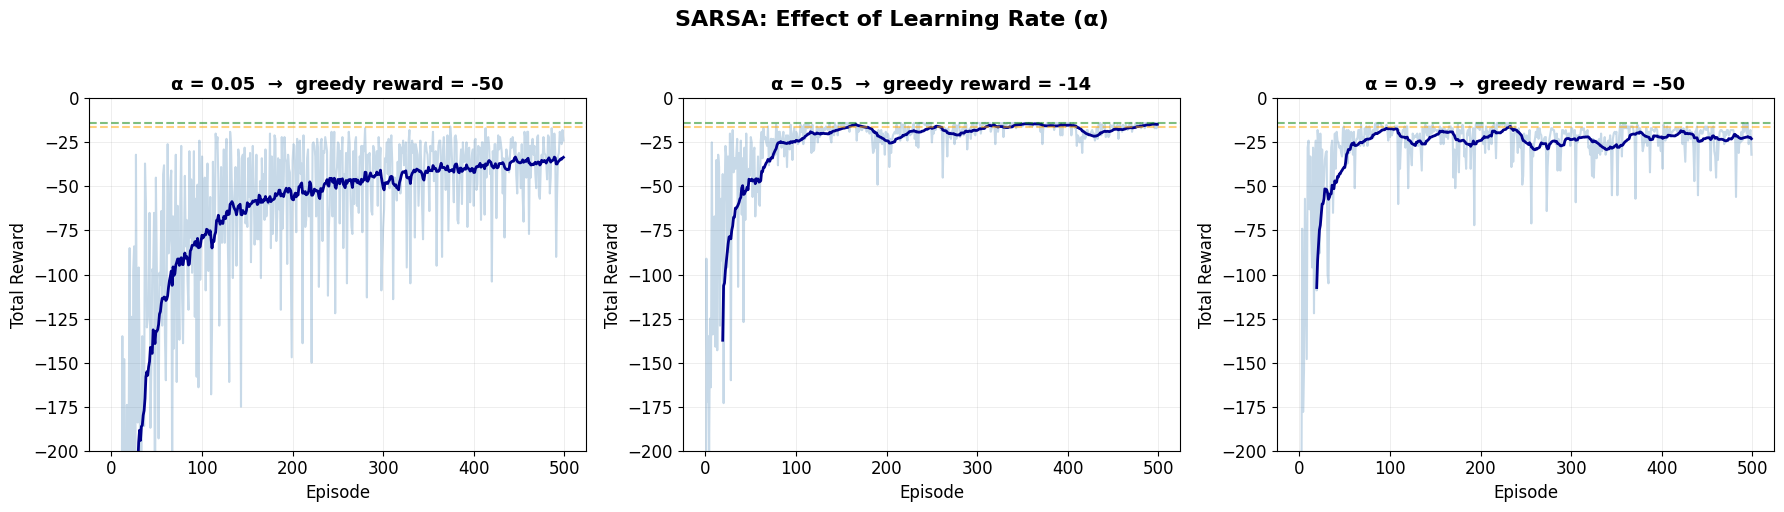

In [31]:
# ── Experiment 1: Learning Rate (α) ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
step_sizes = [0.05, 0.5, 0.9]

for ax, alpha in zip(axes, step_sizes):
    np.random.seed(42)
    env = WindyGridWorld()
    rewards, table = sarsa(env, step_size=alpha, epsilon=0.05, gamma=1.0, num_eps=500)
    total, _ = evaluate_policy(table, env)
    
    ax.plot(rewards, alpha=0.3, color='steelblue')
    window = 20
    rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(rewards)), rolling, color='darkblue', linewidth=2)
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.5)
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.5)
    ax.set_title(f'α = {alpha}  →  greedy reward = {total}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_ylim(-200, 0)
    ax.grid(True, alpha=0.3)

plt.suptitle('SARSA: Effect of Learning Rate (α)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Experiment 2: Effect of Exploration Rate (ε)

**ε controls how often the agent takes random actions.**
- Too small → agent gets stuck exploiting a suboptimal policy early on
- Too large → agent never commits to what it learns, keeps wandering randomly
- Assignment says: keep ε < 10%

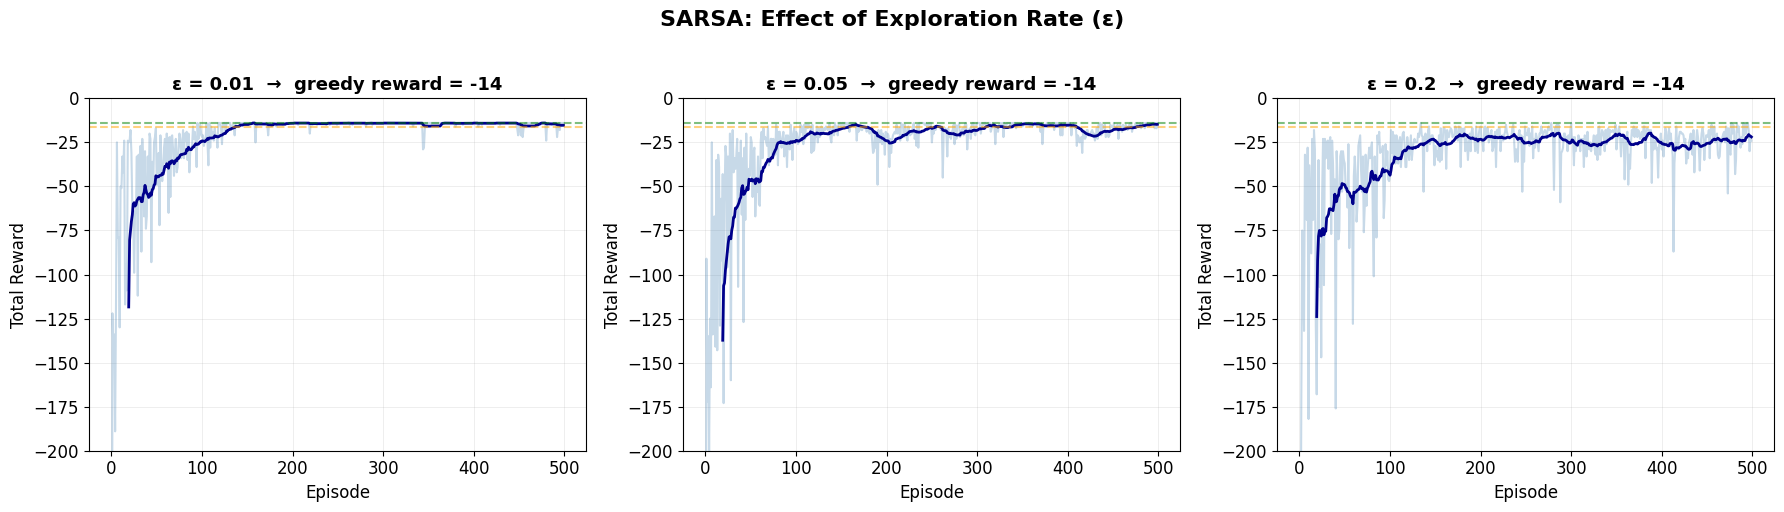

In [32]:
# ── Experiment 2: Exploration Rate (ε) ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epsilons = [0.01, 0.05, 0.20]

for ax, eps in zip(axes, epsilons):
    np.random.seed(42)
    env = WindyGridWorld()
    rewards, table = sarsa(env, step_size=0.5, epsilon=eps, gamma=1.0, num_eps=500)
    total, _ = evaluate_policy(table, env)
    
    ax.plot(rewards, alpha=0.3, color='steelblue')
    window = 20
    rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(rewards)), rolling, color='darkblue', linewidth=2)
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.5)
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.5)
    ax.set_title(f'ε = {eps}  →  greedy reward = {total}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_ylim(-200, 0)
    ax.grid(True, alpha=0.3)

plt.suptitle('SARSA: Effect of Exploration Rate (ε)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Experiment 3: Effect of Number of Episodes

**More episodes = more time to learn.** The key question is: when do rewards flatten?

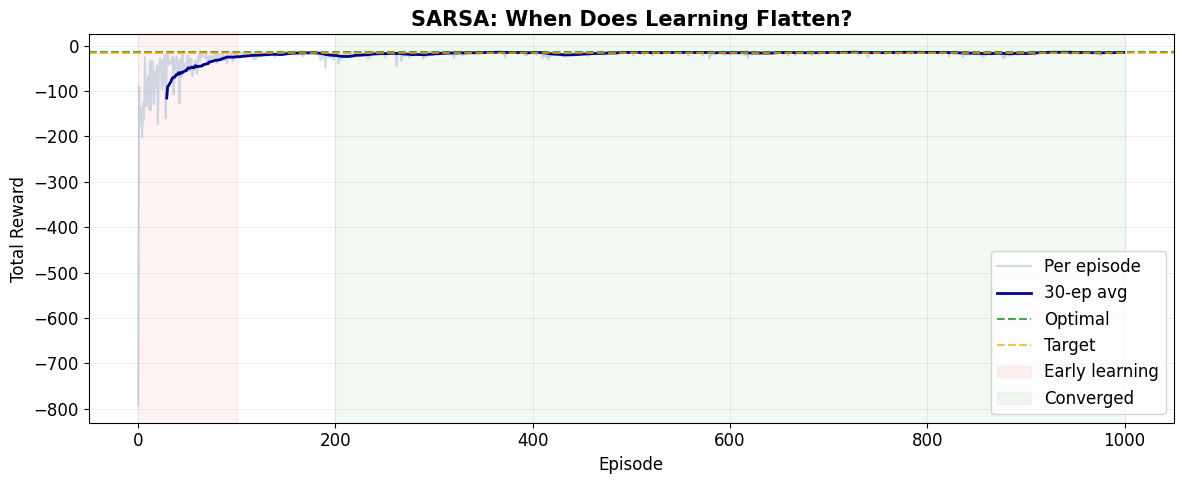

   100 episodes → greedy reward =  -50  ✗
   200 episodes → greedy reward =  -50  ✗
   300 episodes → greedy reward =  -14  ✓
   500 episodes → greedy reward =  -14  ✓


In [33]:
# ── Experiment 3: Number of Episodes ────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

np.random.seed(42)
env = WindyGridWorld()
rewards, table = sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=1000)

ax.plot(rewards, alpha=0.25, color='steelblue', label='Per episode')
window = 30
rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(rewards)), rolling, color='darkblue', linewidth=2, label=f'{window}-ep avg')
ax.axhline(y=-14, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.7, label='Target')

# Mark convergence zones
ax.axvspan(0, 100, alpha=0.05, color='red', label='Early learning')
ax.axvspan(200, 1000, alpha=0.05, color='green', label='Converged')

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('SARSA: When Does Learning Flatten?', fontsize=15, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check convergence at different cutoffs
for cutoff in [100, 200, 300, 500]:
    np.random.seed(42)
    env = WindyGridWorld()
    _, t = sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=cutoff)
    r, _ = evaluate_policy(t, env)
    status = '✓' if r >= -16 else '✗'
    print(f"  {cutoff:4d} episodes → greedy reward = {r:4d}  {status}")

## 11. Understanding the TD Error — The Heart of Both Algorithms

Both SARSA and Q-Learning share this core structure:

```
Q(S,A) ← Q(S,A) + α · [TD Error]
```

Where:
- **TD Target** = R + γ · (future Q estimate)
- **TD Error** = TD Target − Q(S,A)

**Intuition**: The TD error tells the agent "how surprised it is." 
- If TD Error > 0 → the outcome was *better* than expected → increase Q(S,A)
- If TD Error < 0 → the outcome was *worse* than expected → decrease Q(S,A)  
- If TD Error ≈ 0 → our estimate was accurate → Q barely changes (converged!)

The only difference:
- **SARSA**: future estimate = Q(S', A') where A' is the ε-greedy action we'll actually take
- **Q-Learning**: future estimate = max_a Q(S', a) — the best thing we *could* do

This is why Q-Learning is more "optimistic" — it always assumes the best future, while SARSA is realistic about the fact that it'll sometimes explore randomly.

## 12. Summary & Final Parameters

### Recommended Hyperparameters (for both SARSA and Q-Learning)

| Parameter | Value | Reasoning |
|---|---|---|
| **α (step_size)** | `0.5` | Fast enough to learn in 500 episodes, stable enough to converge |
| **ε (epsilon)** | `0.05` | 5% exploration — enough to discover good paths, low enough to exploit them |
| **γ (gamma)** | `1.0` | Required by the assignment (undiscounted episodic task) |
| **num_eps** | `500` | Rewards flatten well before 500 — safe margin |

### What to Put in Your Submitted Files

In **`tabular.py`** — the three code changes:
```python
# Task 1.1 (SARSA update):
q_table[state[0], state[1], action] = q + step_size * (rew + gamma * q_prime - q)

# Task 2.1 (Q-learning best next action):
q_prime = np.max(q_all_actions)

# Task 2.2 (Q-learning update):
q_table[state[0], state[1], action] = q + step_size * (rew + gamma * q_prime - q)
```

In **`main.py`** — tuned parameters for both:
```python
rews, table = tabular.sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=500)
rews, table = tabular.q_learning(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=500)
```

Remember to rename: `tabular_{FNAME}_{LNAME}.py`